In [1]:
#Import Libraries

import re, time, warnings, logging

import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, mean_squared_error,
    PrecisionRecallDisplay, precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor,
)
from xgboost import XGBClassifier, XGBRegressor
import tensorflow as tf
from tensorflow.keras import layers, models
from lightgbm import LGBMClassifier

# ── Global config ───────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)s  %(message)s")
log = logging.getLogger(__name__)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED     = 42
ALERT_THRESHOLD = 15      # µg/m³  (WHO 24-hour PM2.5 guideline)
CV_SPLITS       = 5

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

matplotlib.rcParams.update({"font.size": 12, "figure.figsize": (10, 5)})
print("Setup complete.")


Setup complete.


In [2]:
# Load Data

df1  = pd.read_csv("data-selector-export (1).csv")
df2  = pd.read_csv("data-selector-export (2).csv")
df3  = pd.read_csv("data-selector-export (3).csv")
df4  = pd.read_csv("data-selector-export (4).csv")
df5  = pd.read_csv("data-selector-export (5).csv")
df6  = pd.read_csv("data-selector-export (6).csv")
df7  = pd.read_csv("data-selector-export (7).csv")
df8  = pd.read_csv("data-selector-export (8).csv")
df9  = pd.read_csv("data-selector-export (9).csv")
df10 = pd.read_csv("data-selector-export (10).csv")

##  Data Wrangling

In [3]:
def clean_air_quality_df(df):
    """
    Clean a single wide-format air quality export into long format.

    Steps
    -----
    1. Strip whitespace from Date/Time columns.
    2. Normalise midnight times (24:00 → 00:00 of the next day).
    3. Parse a combined datetime column.
    4. Melt wide PM2.5 and Status columns into long format.
    5. Extract numeric PM2.5 values; coerce non-numeric to NaN.
    6. Sort by datetime.
    """
    df = df.copy()

    df["Date"] = df["Date"].astype(str).str.strip()
    df["Time"] = df["Time"].astype(str).str.strip()

    df["Time"] = df["Time"].str.replace(":00:00", ":00", regex=False)

    mask = df["Time"].str.startswith("24:")
    df.loc[mask, "Time"] = df.loc[mask, "Time"].str.replace("24:", "00:", regex=False)
    df.loc[mask, "Date"] = (
        pd.to_datetime(df.loc[mask, "Date"], dayfirst=True)
        + pd.Timedelta(days=1)
    ).dt.strftime("%d/%m/%Y")

    df["datetime"] = pd.to_datetime(
        df["Date"] + " " + df["Time"],
        format="%d/%m/%Y %H:%M",
        errors="coerce",
    )

    value_cols  = [c for c in df.columns if "PM2.5" in c]
    status_cols = [c for c in df.columns if "Status" in c]

    stations = [
        c.replace(" PM2.5 particulate matter (Hourly measured)", "").strip()
        for c in value_cols
    ]

    value_map  = dict(zip(value_cols,  stations))
    status_map = dict(zip(status_cols, stations))

    values = df[value_cols].rename(columns=value_map)
    status = df[status_cols].rename(columns=status_map)

    values["datetime"] = df["datetime"]
    status["datetime"] = df["datetime"]

    values_long = values.melt(id_vars="datetime", var_name="station", value_name="pm25")
    status_long = status.melt(id_vars="datetime", var_name="station", value_name="status")

    df_long = pd.merge(values_long, status_long, on=["datetime", "station"], how="left")

    df_long["pm25"] = df_long["pm25"].replace("No data", np.nan)
    df_long["pm25"] = (
        df_long["pm25"]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
    )
    df_long["pm25"] = pd.to_numeric(df_long["pm25"], errors="coerce")
    df_long = df_long.sort_values("datetime")

    return df_long

In [4]:
# Joins
dfs         = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10]
cleaned_dfs = [clean_air_quality_df(d) for d in dfs]
df          = pd.concat(cleaned_dfs, ignore_index=True)

print("\n Information")
print(df.info())


 Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1579389 entries, 0 to 1579388
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   datetime  1579389 non-null  datetime64[ns]
 1   station   1579389 non-null  object        
 2   pm25      1313383 non-null  float64       
 3   status    1579389 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 48.2+ MB
None


In [5]:
# Mising values handling

def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute missing PM2.5 values per monitoring station.

    Adds a binary `missing_pm25` column before imputation so downstream
    models can optionally learn from the missingness pattern.
    """
    log.info("Missing PM2.5 before imputation: %d", df["pm25"].isna().sum())
    df = df.copy()
    df["missing_pm25"] = df["pm25"].isna().astype(int)
    df["pm25"] = (
        df.groupby("station")["pm25"]
        .transform(lambda x: x.ffill().interpolate(method="linear"))
    )
    log.info("Missing PM2.5 after imputation:  %d", df["pm25"].isna().sum())
    return df


df = handle_missing(df)
print(df.isnull().sum())


2026-04-16 11:17:06,613  INFO  Missing PM2.5 before imputation: 266006
2026-04-16 11:17:07,104  INFO  Missing PM2.5 after imputation:  132886


datetime             0
station              0
pm25            132886
status               0
missing_pm25         0
dtype: int64


## Exploratory Data Analysis

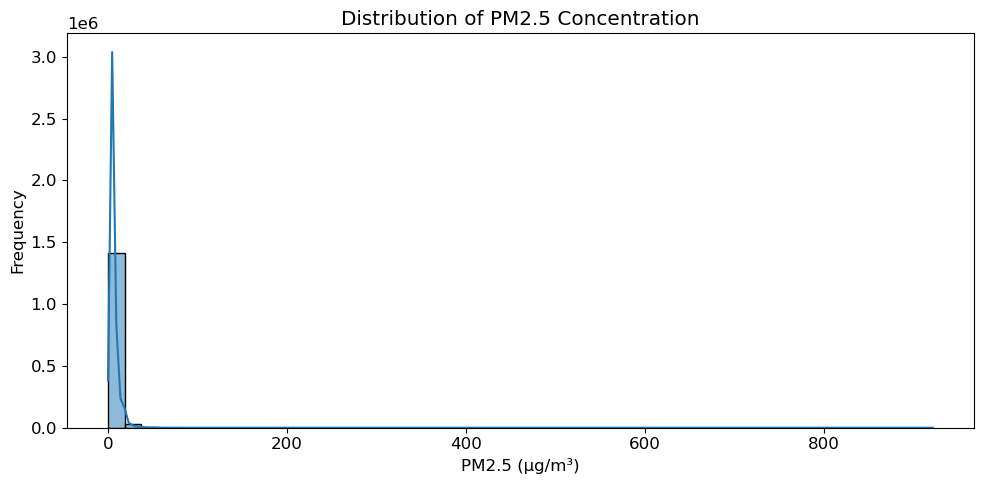

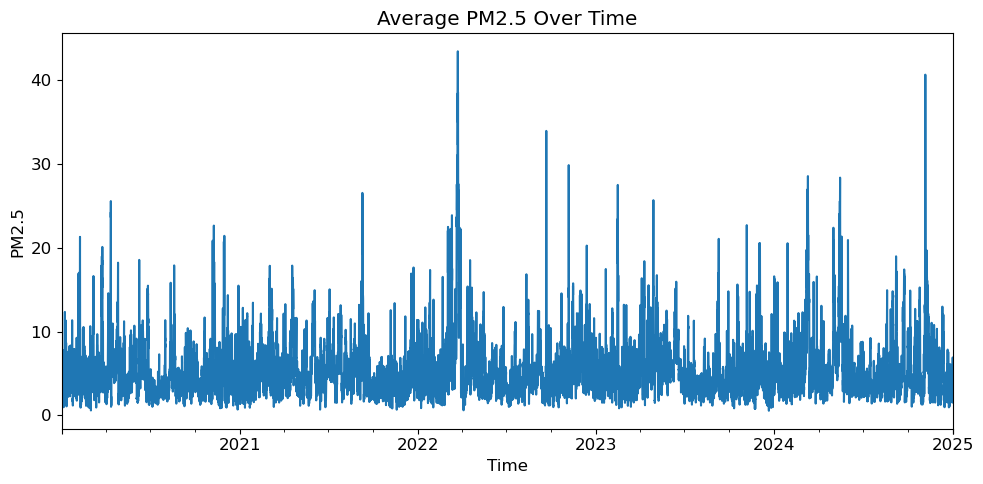

2026-04-16 11:17:15,695  INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-16 11:17:16,659  INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


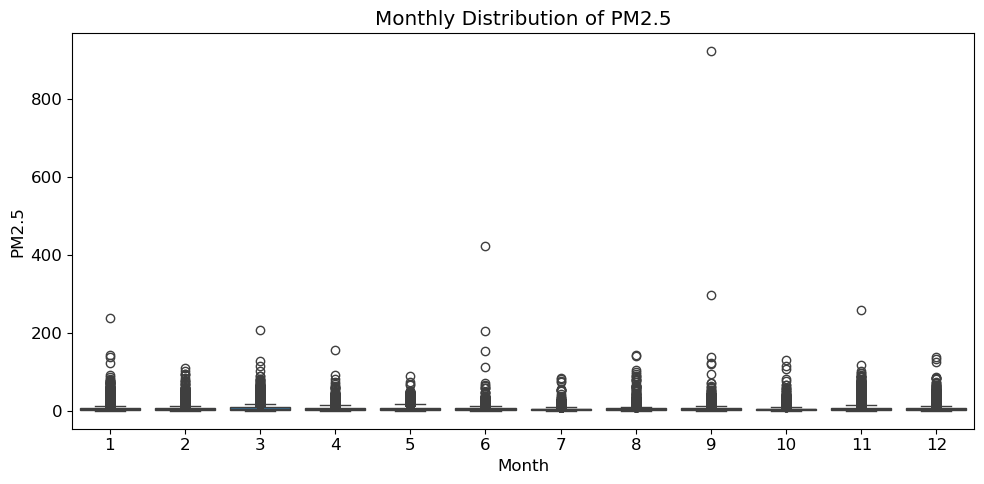

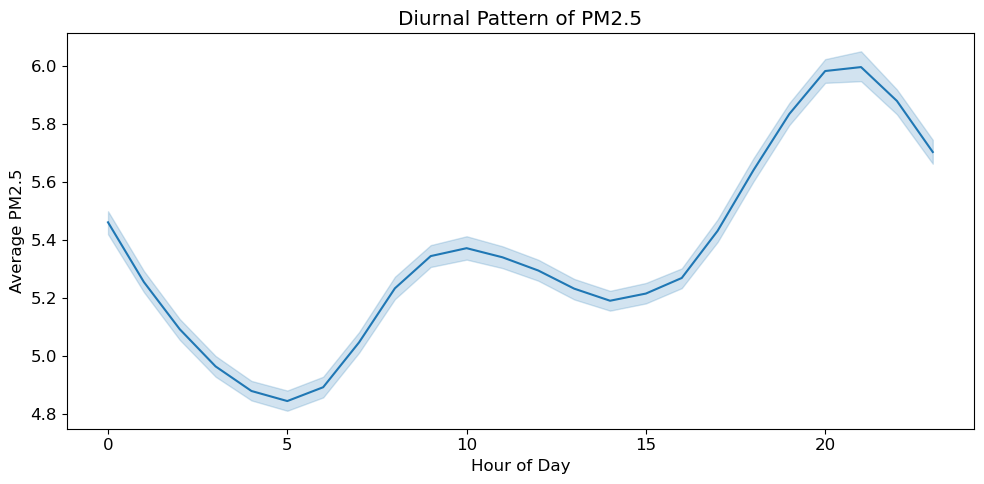

In [6]:
def _show():
    """Finalise and display a plot inline in the notebook."""
    plt.tight_layout()
    plt.show()


def plot_eda(df):
    """Generate four EDA plots inline."""
    # PM2.5 distribution
    plt.figure()
    sns.histplot(df["pm25"], bins=50, kde=True)
    plt.title("Distribution of PM2.5 Concentration")
    plt.xlabel("PM2.5 (µg/m³)")
    plt.ylabel("Frequency")
    _show()

    # Time series of average PM2.5
    plt.figure()
    df.groupby("datetime")["pm25"].mean().plot()
    plt.title("Average PM2.5 Over Time")
    plt.xlabel("Time")
    plt.ylabel("PM2.5")
    _show()

    # Monthly boxplot
    plt.figure()
    sns.boxplot(x=df["datetime"].dt.month, y=df["pm25"])
    plt.title("Monthly Distribution of PM2.5")
    plt.xlabel("Month")
    plt.ylabel("PM2.5")
    _show()

    # Diurnal pattern
    plt.figure()
    sns.lineplot(x=df["datetime"].dt.hour, y=df["pm25"], estimator="mean")
    plt.title("Diurnal Pattern of PM2.5")
    plt.xlabel("Hour of Day")
    plt.ylabel("Average PM2.5")
    _show()


plot_eda(df)


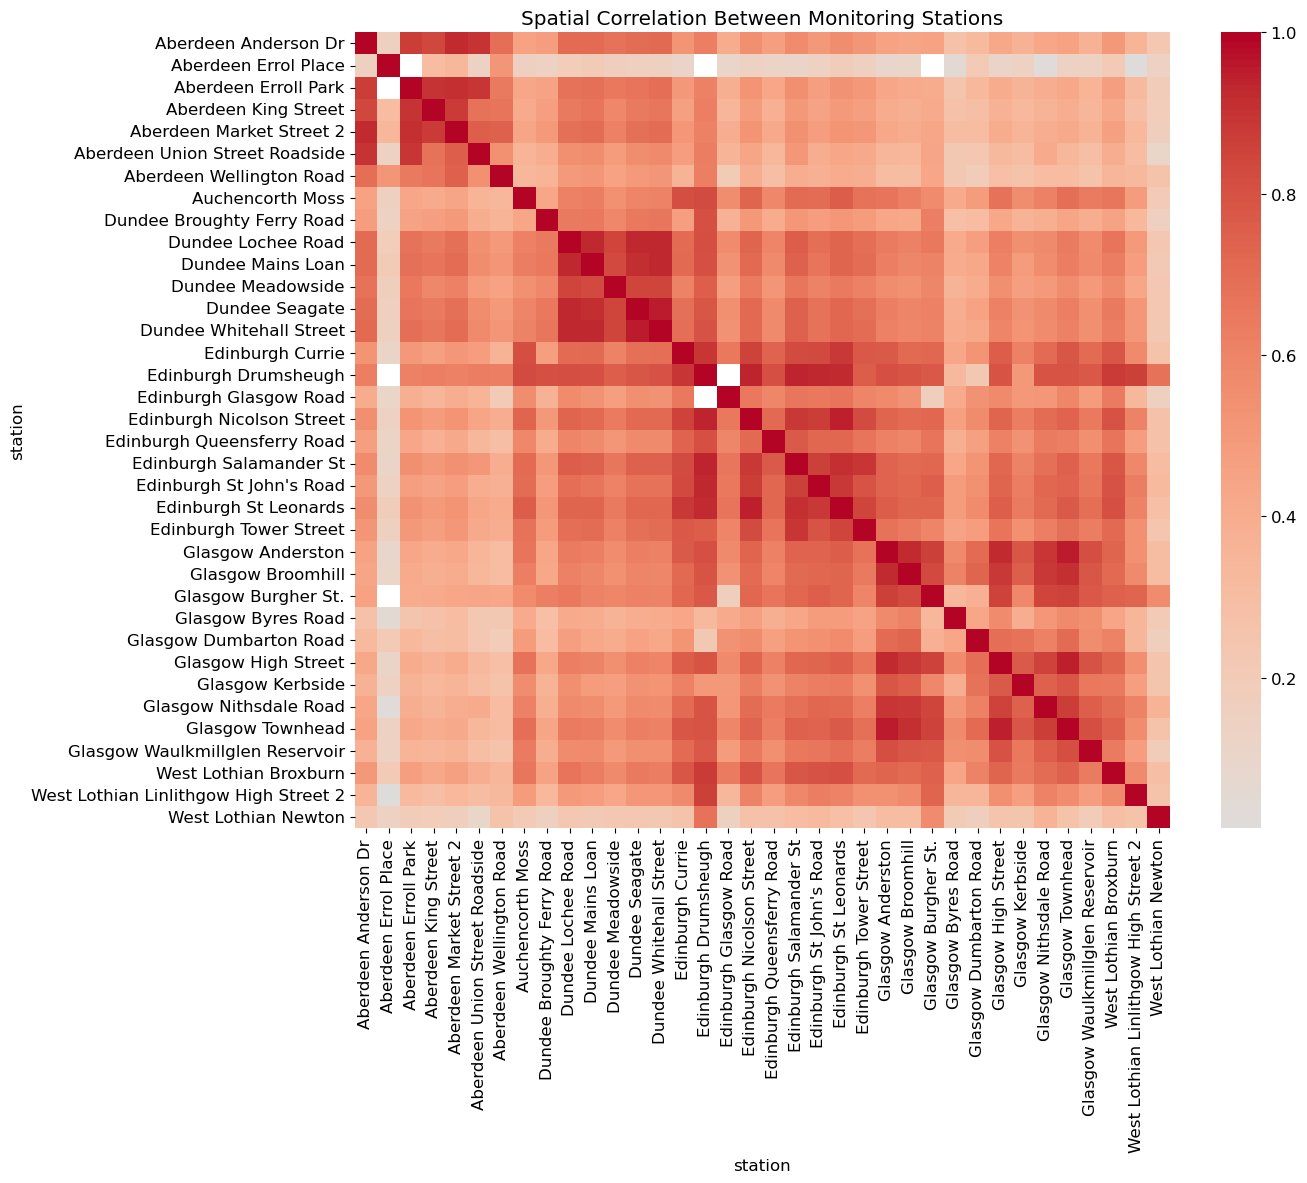

Top 10 correlated station pairs:
station                    station                
Dundee Seagate             Dundee Whitehall Street    0.955116
Glasgow Townhead           Glasgow Anderston          0.952998
                           Glasgow High Street        0.949061
Edinburgh Nicolson Street  Edinburgh St Leonards      0.948258
Edinburgh Drumsheugh       Edinburgh Salamander St    0.938213
Edinburgh Nicolson Street  Edinburgh Drumsheugh       0.937669
Dundee Lochee Road         Dundee Whitehall Street    0.933018
Dundee Mains Loan          Dundee Whitehall Street    0.932514
Dundee Seagate             Dundee Lochee Road         0.928829
Dundee Lochee Road         Dundee Mains Loan          0.928253


In [7]:
def plot_spatial_correlation(df):
    """Plot Pearson correlation heatmap across monitoring stations."""
    pivot = df.pivot_table(index="datetime", columns="station", values="pm25")
    corr  = pivot.corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Spatial Correlation Between Monitoring Stations")
    plt.tight_layout()
    plt.show()

    top = corr.abs().unstack().sort_values(ascending=False)
    top = top[top < 1].drop_duplicates()
    print("Top 10 correlated station pairs:")
    print(top.head(10).to_string())


plot_spatial_correlation(df)


##  Feature Engineering

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build temporal, lag, rolling, and cyclical features.

    All operations are vectorised via pandas groupby.transform — no Python loops.

    """
    df = df.copy()

    # Station-level statistics
    grp = df.groupby("station")["pm25"]
    df["station_mean_pm25"] = grp.transform("mean")
    df["station_std_pm25"]  = grp.transform("std")

    # Temporal components
    df["hour"]  = df["datetime"].dt.hour
    df["month"] = df["datetime"].dt.month

    # Cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Lag features — vectorised
    for lag in [1, 3, 6, 12]:
        df[f"lag_{lag}"] = df.groupby("station")["pm25"].shift(lag)

    # Rolling means — vectorised
    for w in [3, 6, 12, 24]:
        df[f"roll_{w}"] = (
            df.groupby("station")["pm25"]
            .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )

    # Classification target
    df["alert"] = (df["pm25"] > ALERT_THRESHOLD).astype(int)
    df = df.bfill()

    print("Alert class balance:")
    print(df["alert"].value_counts())
    return df


df = engineer_features(df)
df.columns.tolist()


Alert class balance:
alert
0    1519937
1      59452
Name: count, dtype: int64


['datetime',
 'station',
 'pm25',
 'status',
 'missing_pm25',
 'station_mean_pm25',
 'station_std_pm25',
 'hour',
 'month',
 'hour_sin',
 'hour_cos',
 'lag_1',
 'lag_3',
 'lag_6',
 'lag_12',
 'roll_3',
 'roll_6',
 'roll_12',
 'roll_24',
 'alert']

##  Preprocessing

In [9]:
def preprocess(df: pd.DataFrame):
    """
    One-hot encode, split chronologically (80/20), and scale.
    
    """
    df = df.sort_values("datetime").drop(columns=["status"])
    df = pd.get_dummies(df, columns=["station"], drop_first=True)

    # Sanitise for LightGBM (no spaces or special characters in column names)
    df.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in df.columns]

    feature_cols = [c for c in df.columns if c not in ("datetime", "pm25", "alert")]
    X    = df[feature_cols]
    y_cls = df["alert"]
    y_reg = df["pm25"]

    split = int(len(df) * 0.8)
    X_train, X_test         = X.iloc[:split],      X.iloc[split:]
    y_train_cls, y_test_cls = y_cls.iloc[:split],  y_cls.iloc[split:]
    y_train_reg, y_test_reg = y_reg.iloc[:split],  y_reg.iloc[split:]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    log.info("Train: %d | Test: %d | Features: %d",
             len(X_train), len(X_test), X_train.shape[1])
    return (X_train, X_test, y_train_cls, y_test_cls,
            y_train_reg, y_test_reg, X_train_scaled, X_test_scaled, scaler)


(X_train, X_test, y_train_cls, y_test_cls,
 y_train_reg, y_test_reg, X_train_scaled, X_test_scaled, scaler) = preprocess(df)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


2026-04-16 11:17:41,105  INFO  Train: 1263511 | Test: 315878 | Features: 50


Train: (1263511, 50)  |  Test: (315878, 50)


## 7  |  Hyperparameter Tuning (Random Forest)

In [10]:
def tune_random_forest(X_train, y_train_cls) -> RandomForestClassifier:
    """Quick random search over Random Forest hyperparameters."""
    param_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 10]}
    rf     = RandomForestClassifier(class_weight="balanced",
                                    random_state=RANDOM_SEED, n_jobs=-1)
    search = RandomizedSearchCV(rf, param_grid, n_iter=5, cv=3,
                                random_state=RANDOM_SEED, n_jobs=-1)
    search.fit(X_train, y_train_cls)
    log.info("Best RF params: %s", search.best_params_)
    return search.best_estimator_


best_rf = tune_random_forest(X_train, y_train_cls)


2026-04-16 11:24:17,970  INFO  Best RF params: {'n_estimators': 100, 'max_depth': 10}


In [11]:
def build_classifiers(y_train_cls: pd.Series) -> dict:
    """Return classification models with built-in class imbalance handling."""
    neg, pos = (y_train_cls == 0).sum(), (y_train_cls == 1).sum()
    scale_pos = neg / pos if pos > 0 else 1.0

    return {
        "Logistic":  LogisticRegression(class_weight="balanced", max_iter=1000,
                                        random_state=RANDOM_SEED),
        "RF":        best_rf,
        "GB":        GradientBoostingClassifier(random_state=RANDOM_SEED),
        "XGB":       XGBClassifier(eval_metric="logloss", scale_pos_weight=scale_pos,
                                   random_state=RANDOM_SEED, verbosity=0),
        "XGB_Tuned": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                   scale_pos_weight=scale_pos, eval_metric="logloss",
                                   random_state=RANDOM_SEED, verbosity=0),
        "LightGBM":  LGBMClassifier(n_estimators=200, scale_pos_weight=scale_pos,
                                    random_state=RANDOM_SEED, verbose=-1),
    }


def build_regressors() -> dict:
    """Return regression models."""
    return {
        "Linear": LinearRegression(),
        "RF":     RandomForestRegressor(n_jobs=-1, random_state=RANDOM_SEED),
        "GB":     GradientBoostingRegressor(random_state=RANDOM_SEED),
        "XGB":    XGBRegressor(random_state=RANDOM_SEED, verbosity=0),
    }


def build_tiny_nn(input_dim: int) -> tf.keras.Model:
    """Small feedforward classifier: Dense(32) → Dense(16) → Dense(1, sigmoid)."""
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(32, activation="relu")(inp)
    x   = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1,  activation="sigmoid")(x)
    model = models.Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["AUC"])
    return model


cls_models = build_classifiers(y_train_cls)
reg_models = build_regressors()
print("Classifiers:", list(cls_models.keys()))
print("Regressors: ", list(reg_models.keys()))


Classifiers: ['Logistic', 'RF', 'GB', 'XGB', 'XGB_Tuned', 'LightGBM']
Regressors:  ['Linear', 'RF', 'GB', 'XGB']


In [12]:
def _tune_threshold(y_true, y_prob) -> float:
    """Return the probability threshold that maximises F1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return float(thresholds[np.argmax(f1)])


def evaluate_classifier(name, model, X_train, X_test,
                        y_train, y_test, is_nn=False) -> dict:
    """
    Fit, predict, tune threshold, and log metrics for one classifier.

    """
    t0 = time.time()
    if is_nn:
        model.fit(X_train, y_train, epochs=20, batch_size=256,
                  validation_split=0.2, verbose=0)
        y_prob = model.predict(X_test, verbose=0).flatten()
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    duration  = time.time() - t0
    roc       = roc_auc_score(y_test, y_prob)
    threshold = _tune_threshold(y_test, y_prob)
    y_pred    = (y_prob >= threshold).astype(int)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  ROC-AUC: {roc:.4f}  |  Time: {duration:.1f}s  |  Threshold: {threshold:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred))
    return {"Model": name, "ROC-AUC": roc, "Time": duration, "Threshold": threshold}


def evaluate_regressor(name, model, X_train, X_test,
                       y_train, y_test) -> dict:
    """Fit and evaluate one regression model."""
    t0   = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    duration = time.time() - t0
    print(f"{name:12s}  RMSE: {rmse:.4f}  |  Time: {duration:.1f}s")
    return {"Model": name, "RMSE": rmse, "Time": duration}


##  Classification Evaluation

In [13]:
cls_results = []
y_prob_best = None
best_roc    = -1

for name, model in cls_models.items():
    if name == "Logistic":
        result = evaluate_classifier(name, model,
                                     X_train_scaled, X_test_scaled,
                                     y_train_cls, y_test_cls)
    else:
        result = evaluate_classifier(name, model,
                                     X_train, X_test,
                                     y_train_cls, y_test_cls)
    cls_results.append(result)

    # Keep predictions of the best model for the PR curve
    if result["ROC-AUC"] > best_roc:
        best_roc = result["ROC-AUC"]
        _X = X_test_scaled if name == "Logistic" else X_test
        if hasattr(model, "predict_proba"):
            y_prob_best = model.predict_proba(_X)[:, 1]

pd.DataFrame(cls_results).sort_values("ROC-AUC", ascending=False)



  Logistic
  ROC-AUC: 0.9709  |  Time: 9.4s  |  Threshold: 0.9291
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    294816
           1       0.89      0.90      0.90     21062

    accuracy                           0.99    315878
   macro avg       0.94      0.95      0.94    315878
weighted avg       0.99      0.99      0.99    315878


  RF
  ROC-AUC: 0.9944  |  Time: 40.0s  |  Threshold: 0.9199
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    294816
           1       0.87      0.87      0.87     21062

    accuracy                           0.98    315878
   macro avg       0.93      0.93      0.93    315878
weighted avg       0.98      0.98      0.98    315878


  GB
  ROC-AUC: 0.9975  |  Time: 459.7s  |  Threshold: 0.4739
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    294816
           1       0.91      0.91      0.91  

,Model,ROC-AUC,Time,Threshold
4,XGB_Tuned,0.997987,11.947886,0.953647
5,LightGBM,0.997968,9.388181,0.961720
3,XGB,0.997929,7.051736,0.940033
2,GB,0.997531,459.736488,0.473904
1,RF,0.994446,39.956612,0.919861
0,Logistic,0.970885,9.419989,0.929073


###  Tiny Neural Network

In [14]:
scaler_nn  = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn  = scaler_nn.transform(X_test)

tiny_nn   = build_tiny_nn(X_train_nn.shape[1])
nn_result = evaluate_classifier("TinyNN", tiny_nn,
                                X_train_nn, X_test_nn,
                                y_train_cls, y_test_cls,
                                is_nn=True)
cls_results.append(nn_result)

pd.DataFrame(cls_results).sort_values("ROC-AUC", ascending=False)


2026-04-16 11:33:20,949  WARNING  TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.



  TinyNN
  ROC-AUC: 0.9918  |  Time: 126.6s  |  Threshold: 0.3382
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    294816
           1       0.87      0.91      0.89     21062

    accuracy                           0.98    315878
   macro avg       0.93      0.95      0.94    315878
weighted avg       0.99      0.98      0.98    315878



,Model,ROC-AUC,Time,Threshold
4,XGB_Tuned,0.997987,11.947886,0.953647
5,LightGBM,0.997968,9.388181,0.961720
3,XGB,0.997929,7.051736,0.940033
2,GB,0.997531,459.736488,0.473904
1,RF,0.994446,39.956612,0.919861
6,TinyNN,0.991768,126.627094,0.338237
0,Logistic,0.970885,9.419989,0.929073


##  Time-Series Cross-Validation

In [15]:
def time_series_cv(cls_models: dict, X, y_cls, n_splits: int = CV_SPLITS) -> None:
    """Walk-forward cross-validation for all classifiers except GB."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    skip = {"GB"}

    for name, model in cls_models.items():
        if name in skip:
            print(f"{name}: skipped in CV (slow; hold-out evaluation sufficient)")
            continue
        scores = []
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y_cls.iloc[train_idx], y_cls.iloc[val_idx]
            model.fit(X_tr, y_tr)
            y_prob = model.predict_proba(X_val)[:, 1]
            scores.append(roc_auc_score(y_val, y_prob))
        print(f"{name:12s}  CV ROC-AUC: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


time_series_cv(cls_models, X_train, y_train_cls)


Logistic      CV ROC-AUC: 0.9925 ± 0.0038
RF            CV ROC-AUC: 0.9947 ± 0.0011
GB: skipped in CV (slow; hold-out evaluation sufficient)
XGB           CV ROC-AUC: 0.9972 ± 0.0008
XGB_Tuned     CV ROC-AUC: 0.9973 ± 0.0008
LightGBM      CV ROC-AUC: 0.9972 ± 0.0007


##  Regression Evaluation

In [16]:
print("\n Regression Results")
reg_results = [
    evaluate_regressor(name, model, X_train, X_test, y_train_reg, y_test_reg)
    for name, model in reg_models.items()
]
pd.DataFrame(reg_results).sort_values("RMSE")



 Regression Results
Linear        RMSE: 1.1393  |  Time: 1.6s
RF            RMSE: 1.1092  |  Time: 506.8s
GB            RMSE: 1.2288  |  Time: 447.8s
XGB           RMSE: 1.2616  |  Time: 5.7s


,Model,RMSE,Time
1,RF,1.109242,506.800466
0,Linear,1.139340,1.605515
2,GB,1.228753,447.784899
3,XGB,1.261584,5.696689


##  Result Visualisation

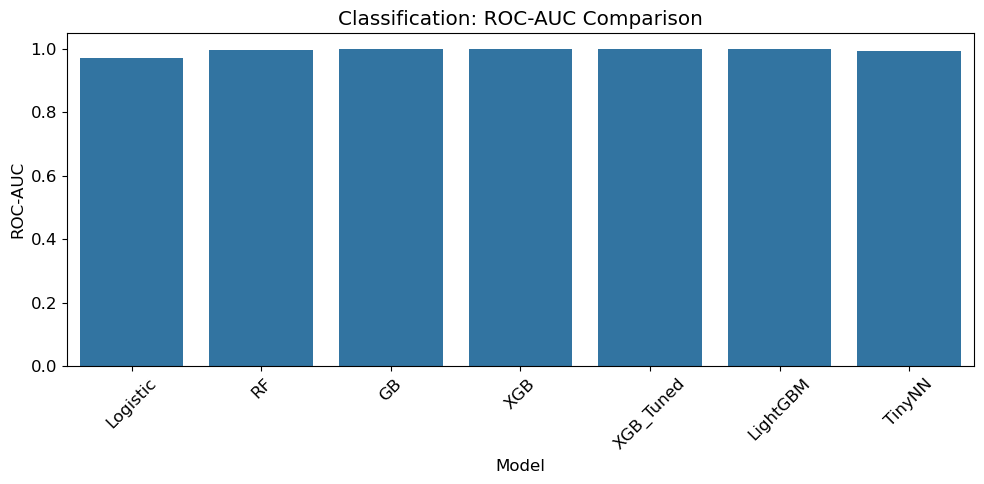

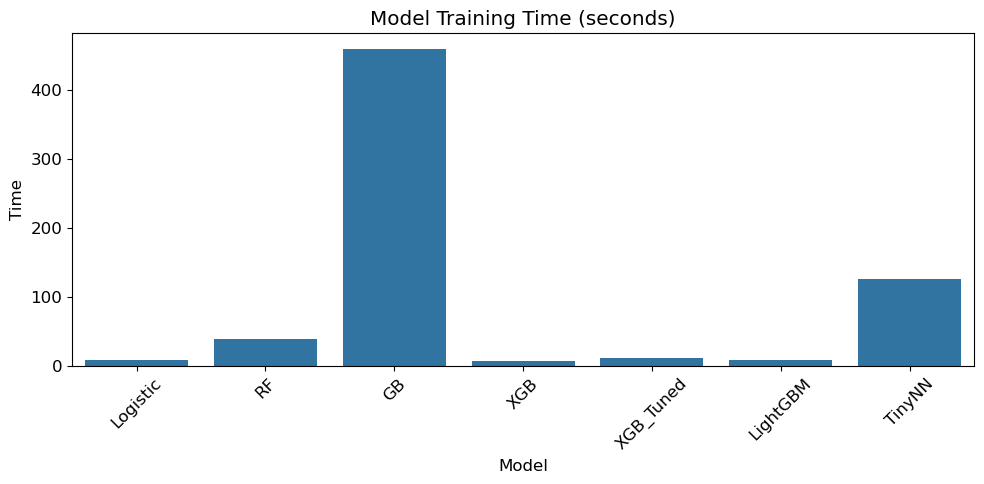

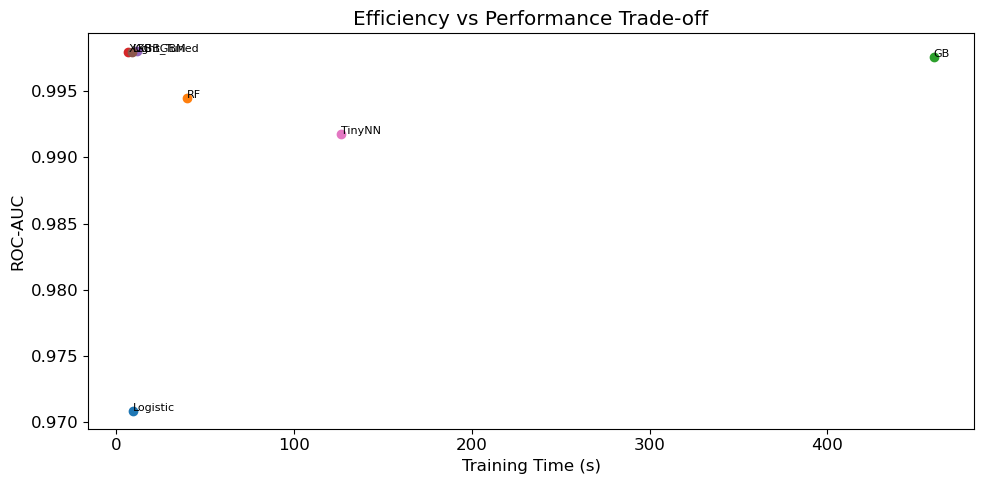

<Figure size 1000x500 with 0 Axes>

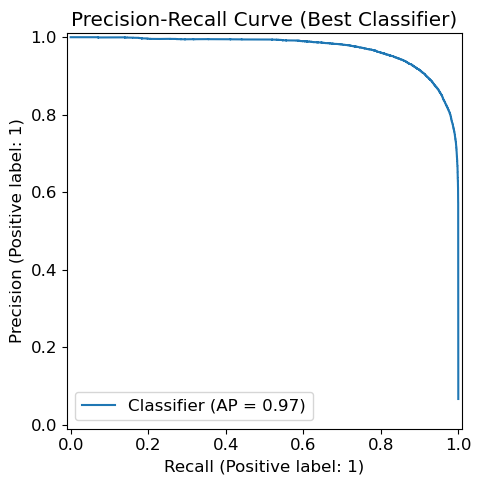

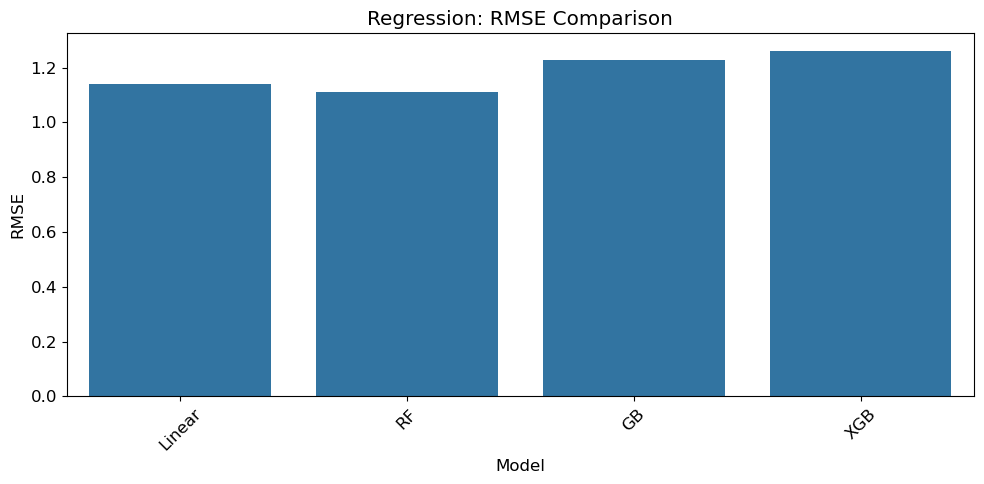

In [17]:
def plot_results(cls_results, reg_results, y_test_cls, y_prob_best):
    """Display model comparison plots inline."""
    cls_df = pd.DataFrame(cls_results)
    reg_df = pd.DataFrame(reg_results)

    # ROC-AUC comparison
    plt.figure()
    sns.barplot(x="Model", y="ROC-AUC", data=cls_df)
    plt.title("Classification: ROC-AUC Comparison")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Training time
    plt.figure()
    sns.barplot(x="Model", y="Time", data=cls_df)
    plt.title("Model Training Time (seconds)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Efficiency scatter
    plt.figure()
    for _, row in cls_df.iterrows():
        plt.scatter(row["Time"], row["ROC-AUC"])
        plt.text(row["Time"], row["ROC-AUC"], row["Model"], fontsize=8)
    plt.xlabel("Training Time (s)")
    plt.ylabel("ROC-AUC")
    plt.title("Efficiency vs Performance Trade-off")
    plt.tight_layout()
    plt.show()

    # Precision-recall curve (best model)
    if y_prob_best is not None:
        plt.figure()
        PrecisionRecallDisplay.from_predictions(y_test_cls, y_prob_best)
        plt.title("Precision-Recall Curve (Best Classifier)")
        plt.tight_layout()
        plt.show()

    # Regression RMSE
    plt.figure()
    sns.barplot(x="Model", y="RMSE", data=reg_df)
    plt.title("Regression: RMSE Comparison")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_results(cls_results, reg_results, y_test_cls, y_prob_best)


## Save Models

In [18]:
joblib.dump(best_rf, "thbest_rf_model.pkl")
joblib.dump(scaler,  "thscaler.pkl")
print("Saved: thbest_rf_model.pkl  thscaler.pkl")

print("\nSummary Models")
print("\nClassification:")
print(pd.DataFrame(cls_results).sort_values("ROC-AUC", ascending=False).to_string(index=False))
print("\nRegression:")
print(pd.DataFrame(reg_results).sort_values("RMSE").to_string(index=False))
print("\nPipeline complete.")


Saved: thbest_rf_model.pkl  thscaler.pkl

Summary Models

Classification:
    Model  ROC-AUC       Time  Threshold
XGB_Tuned 0.997987  11.947886   0.953647
 LightGBM 0.997968   9.388181   0.961720
      XGB 0.997929   7.051736   0.940033
       GB 0.997531 459.736488   0.473904
       RF 0.994446  39.956612   0.919861
   TinyNN 0.991768 126.627094   0.338237
 Logistic 0.970885   9.419989   0.929073

Regression:
 Model     RMSE       Time
    RF 1.109242 506.800466
Linear 1.139340   1.605515
    GB 1.228753 447.784899
   XGB 1.261584   5.696689

Pipeline complete.


##  Inference 

In [19]:
# Load saved artefacts
model_loaded  = joblib.load("thbest_rf_model.pkl")
scaler_loaded = joblib.load("thscaler.pkl")

# X_new must have the same columns as X_train
# Example: score the first 5 rows of the test set
X_sample = X_test.iloc[:5]
preds    = model_loaded.predict(X_sample)
probs    = model_loaded.predict_proba(X_sample)[:, 1]

pd.DataFrame({"alert_pred": preds, "alert_prob": probs.round(4)})


,alert_pred,alert_prob
0,0,0.0069
1,0,0.0120
2,0,0.0137
3,0,0.0074
4,1,0.7918


In [20]:
# Save the best regressor
joblib.dump(reg_models["RF"], "best_reg_model.pkl")

['best_reg_model.pkl']

In [22]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error

# Fit a dedicated scaler for the regression task
scaler_reg     = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled  = scaler_reg.transform(X_test)

# Train Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)

# Check RMSE
preds_lr = lr_reg.predict(X_test_scaled)
rmse_lr  = np.sqrt(mean_squared_error(y_test_reg, preds_lr))
print(f"Linear Regression RMSE: {rmse_lr:.4f} µg/m³")

# Save as wrapped dict for the dashboard
joblib.dump(
    {"model": lr_reg, "scaler": scaler_reg, "type": "linear"},
    "best_reg_model.pkl"
)
print("Saved best_reg_model.pkl")

Linear Regression RMSE: 1.1393 µg/m³
Saved best_reg_model.pkl
